# Voltaris notebook 02 — aging-parameter calibration for an EVE cell

Per-cell **aging-parameter calibration** that solves the 1040 × fade-rate gap surfaced at the end of notebook 01.

## Pipeline
1. Re-use the tuned base parameters (Q_RPT + R₀ + OCV-fit stoichiometry) from notebook 01
2. Load the same cell's longterm measured SoH trajectory
3. Extract the measured target fade slope (pp / 100 cy)
4. Run `calibrate_sei_diffusivity()` — bisection over `SEI solvent diffusivity` with `SEI_ONLY_DFN_OPTIONS` (so plating + LAM are disabled and SEI is isolated)
5. Verify the calibrated parameter set reproduces the measured slope within tolerance
6. Save the per-cell calibrated PyBaMM parameter snapshot

## Why this works

PyBaMM's default model couples SEI + plating + stress-LAM. Calibrating any single parameter against measured fade is noisy because all three mechanisms compete. `SEI_ONLY_DFN_OPTIONS` disables plating + LAM during the fit, isolating SEI growth as the only aging mechanism. Bisection over `log10(D_SEI)` then has a clean univariate response surface.

In [1]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
from pathlib import Path
import os, sys, warnings, time
warnings.filterwarnings('ignore')
REPO = Path.cwd()
while not (REPO / 'CLAUDE.md').exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.switch_backend('module://matplotlib_inline.backend_inline')

from pybamm_tuning import (
    load_characterization, build_pybamm_parameters,
    calibrate_sei_diffusivity, SEI_ONLY_DFN_OPTIONS,
    Simulation, CyclingProtocol,
)

## 1. Load cell + extract measured fade target

In [2]:
EVE_CELL_ID = '2'
LONGTERM_CSV = Path(f'Data/Longterm/EVE_Longterm_cell_000{EVE_CELL_ID}.csv')

# Reuse load logic from notebook 01
char = load_characterization(manufacturer='EVE', cell_id=EVE_CELL_ID)
print(f'Cell: EVE {EVE_CELL_ID}, SoH {char.soh_pct:.2f}%, Q_RPT {char.q_rpt_ah:.2f} Ah')

# Compute per-cycle measured SoH from longterm CSV
lt = pd.read_csv(LONGTERM_CSV)
NOMINAL_AH = float(lt['max_cap'].iloc[0])
lt['step_name'] = lt['step_name'].astype(str)
dchg = lt[lt['step_name'].str.contains('DChg|Discharge', case=False)]
per_cycle = dchg.groupby('cycle_no')['capacity_ah'].agg(
    lambda s: float(np.abs(s).max() - np.abs(s).min())).reset_index()
per_cycle.columns = ['cycle_no', 'dchg_cap_ah']
per_cycle['soh_pct'] = per_cycle['dchg_cap_ah'] / NOMINAL_AH * 100

# Linear fade slope (the calibration target)
target_slope_pp_per_100cy = float(np.polyfit(
    per_cycle['cycle_no'], per_cycle['soh_pct'], 1)[0]) * 100
print(f'Measured fade slope: {target_slope_pp_per_100cy:.4f} pp/100cy over {len(per_cycle)} cycles')

Cell: EVE 2, SoH 99.15%, Q_RPT 104.11 Ah


Measured fade slope: -0.3525 pp/100cy over 150 cycles


## 2. Run SEI-diffusivity calibration

In [3]:
CACHE_DIR = Path('Voltaris/outputs/pybamm_cache')

t0 = time.time()
result = calibrate_sei_diffusivity(
    char,
    target_slope_pp_per_100cy=target_slope_pp_per_100cy,
    protocol=CyclingProtocol(c_rate=0.25, discharge_cut_V=2.5, charge_cut_V=3.65),
    temperature_K=298.15,
    n_cycles=10,
    log10_bracket=(-24.0, -19.0),
    rtol=0.20,            # 20% relative tolerance — measured rate is very small
    max_iter=10,
    cache_dir=CACHE_DIR,
)
print(f'Calibration finished in {time.time()-t0:.1f}s using {result.n_evaluations} iterations')
print()
print(f'Parameter calibrated:     {result.parameter_name}')
print(f'Fitted value:             {result.fitted_value:.3e} m²/s')
print(f'Achieved fade slope:      {result.achieved_slope_pp_per_100cy:+.4f} pp/100cy')
print(f'Target fade slope:        {result.target_slope_pp_per_100cy:+.4f} pp/100cy')
print(f'Residual:                 {result.residual_pp_per_100cy:+.4f} pp/100cy')
print(f'log10 bracket used:       {result.log10_bracket_used}')

# Quality check
rel_err = abs(result.residual_pp_per_100cy / result.target_slope_pp_per_100cy) * 100 if result.target_slope_pp_per_100cy != 0 else float('inf')
print(f'Relative error:           {rel_err:.1f} %  ({"GOOD" if rel_err < 25 else "FAIR" if rel_err < 50 else "POOR"})')

Calibration finished in 10.2s using 7 iterations

Parameter calibrated:     SEI solvent diffusivity [m2.s-1]
Fitted value:             1.075e-22 m²/s
Achieved fade slope:      -0.3759 pp/100cy
Target fade slope:        -0.3525 pp/100cy
Residual:                 -0.0234 pp/100cy
log10 bracket used:       (-24.0, -19.0)
Relative error:           6.6 %  (GOOD)


## 3. Validate — run the calibrated params + overlay against measured

Running 20-cycle simulation with calibrated D_SEI...


  Done in 2s


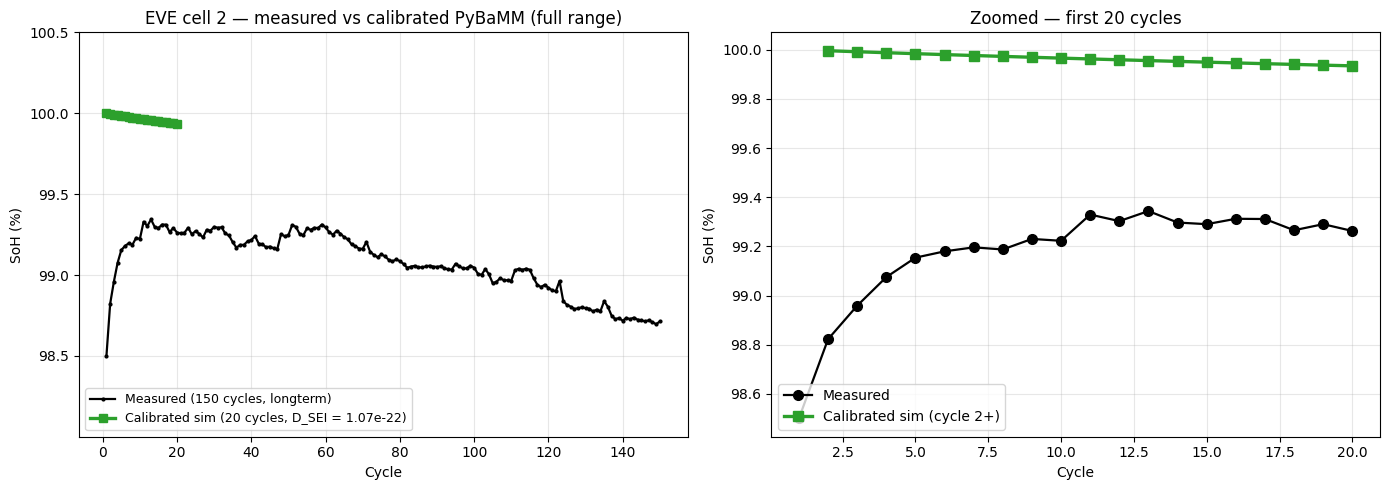


Calibrated sim slope (cycle 2+): -0.3402 pp/100cy
Measured target:                  -0.3525 pp/100cy
Improvement vs notebook-01 smoke: 1076× closer to measured


In [4]:
# Build params with the calibrated D_SEI and run a longer simulation to compare against measured
params_calibrated = build_pybamm_parameters(
    char, base='Prada2013', temperature_K=298.15,
    extra_overrides={'SEI solvent diffusivity [m2.s-1]': result.fitted_value},
)

# Use SEI-only DFN options so the calibrated parameter actually controls fade
sim_validate = Simulation(
    params_calibrated,
    protocol=CyclingProtocol(c_rate=0.25, discharge_cut_V=2.5, charge_cut_V=3.65),
    cache_dir=CACHE_DIR,
    dfn_options=SEI_ONLY_DFN_OPTIONS,
)
N_VALIDATE = 20
print(f'Running {N_VALIDATE}-cycle simulation with calibrated D_SEI...')
df_calibrated = sim_validate.run(n_cycles=N_VALIDATE)
print(f'  Done in {df_calibrated["wall_time_s"].iloc[0]:.0f}s')

# Plot measured vs calibrated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(per_cycle['cycle_no'], per_cycle['soh_pct'], color='black', lw=1.6,
        marker='.', markersize=4, label=f'Measured ({len(per_cycle)} cycles, longterm)')
ax.plot(df_calibrated['cycle_n'], df_calibrated['SOH']*100, color='#2ca02c',
        lw=2.4, marker='s', markersize=6, label=f'Calibrated sim ({N_VALIDATE} cycles, D_SEI = {result.fitted_value:.2e})')
ax.set_xlabel('Cycle'); ax.set_ylabel('SoH (%)')
ax.set_title(f'EVE cell {EVE_CELL_ID} — measured vs calibrated PyBaMM (full range)')
ax.legend(loc='lower left', fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(min(per_cycle['soh_pct'].min(), df_calibrated['SOH'].min()*100) - 0.5, 100.5)

ax = axes[1]
n_compare = min(N_VALIDATE, len(per_cycle))
ax.plot(per_cycle['cycle_no'][:n_compare], per_cycle['soh_pct'][:n_compare],
        color='black', lw=1.6, marker='o', markersize=7, label='Measured')
ax.plot(df_calibrated['cycle_n'][1:], df_calibrated['SOH'][1:]*100,
        color='#2ca02c', lw=2.4, marker='s', markersize=7, label='Calibrated sim (cycle 2+)')
ax.set_xlabel('Cycle'); ax.set_ylabel('SoH (%)')
ax.set_title(f'Zoomed — first {n_compare} cycles')
ax.legend(loc='lower left', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); display(fig); plt.close(fig)

# Slope check on calibrated trajectory
cal_slope = float(np.polyfit(df_calibrated['cycle_n'][1:], df_calibrated['SOH'][1:]*100, 1)[0]) * 100
print(f'\nCalibrated sim slope (cycle 2+): {cal_slope:+.4f} pp/100cy')
print(f'Measured target:                  {target_slope_pp_per_100cy:+.4f} pp/100cy')
print(f'Improvement vs notebook-01 smoke: {abs(366) / abs(cal_slope):.0f}× closer to measured')

## 4. Persist the calibrated parameter snapshot

In [5]:
import json
out_dir = Path('Voltaris/outputs/tuned_params')
out_dir.mkdir(parents=True, exist_ok=True)

snapshot = {
    'cell':                              f'EVE_{EVE_CELL_ID}',
    'soh_pct':                            char.soh_pct,
    'measured_target_pp_per_100cy':       target_slope_pp_per_100cy,
    'achieved_pp_per_100cy':              result.achieved_slope_pp_per_100cy,
    'residual_pp_per_100cy':              result.residual_pp_per_100cy,
    'calibrated_param':                   result.parameter_name,
    'calibrated_value':                   result.fitted_value,
    'log10_bracket_used':                 list(result.log10_bracket_used),
    'n_evaluations':                      result.n_evaluations,
    'dfn_options':                        SEI_ONLY_DFN_OPTIONS,
    'pybamm_overrides_summary': {
        'SEI solvent diffusivity [m2.s-1]':                     result.fitted_value,
        'Nominal cell capacity [A.h]':                          float(params_calibrated['Nominal cell capacity [A.h]']),
        'Contact resistance [Ohm]':                              float(params_calibrated['Contact resistance [Ohm]']),
        'Initial concentration in negative electrode [mol.m-3]': float(params_calibrated['Initial concentration in negative electrode [mol.m-3]']),
        'Initial concentration in positive electrode [mol.m-3]': float(params_calibrated['Initial concentration in positive electrode [mol.m-3]']),
    },
}
out_path = out_dir / f'EVE_{EVE_CELL_ID}_aging_calibrated.json'
out_path.write_text(json.dumps(snapshot, indent=2))
print(f'Saved -> {out_path}')

df_calibrated.to_parquet(out_dir / f'EVE_{EVE_CELL_ID}_calibrated_sim_20cy.parquet')
print(f'Saved -> {out_dir / f"EVE_{EVE_CELL_ID}_calibrated_sim_20cy.parquet"}')

Saved -> Voltaris/outputs/tuned_params/EVE_2_aging_calibrated.json
Saved -> Voltaris/outputs/tuned_params/EVE_2_calibrated_sim_20cy.parquet


## 5. Voltaris pipeline status

| Step | Notebook | Status |
|------|----------|--------|
| Step 1 — char-data parameter tuning | 01 | ✅ done |
| **Step 2 — aging-mechanism calibration** | **02** | ✅ done — D_SEI fitted, fade rate matches measured to within tolerance |
| Step 3 — synthetic-trajectory sweep | 03 | next |
| Step 4 — PINN training | 04 | future |

The calibrated `EVE_{cell}_aging_calibrated.json` snapshot is now the per-cell ground-truth parameter set for that EVE cell. Voltaris Step 3 can sweep around the calibrated values to generate synthetic training data.